# Borrower Optionality Score

**What this is**: an application of established option-theoretic mortgage valuation (Kau, Keenan, Muller, Epperson et al.) -- a mortgage is a bundle of two options the borrower holds: a **put option to default** (in the money when equity goes negative) and a **call option to prepay/refinance** (in the money when market rates drop below the borrower's rate). This notebook computes both option "moneyness" values per loan and combines them into a business-facing score: *not* "will this borrower default" (that's the PD model), but *"if trouble hits, can they self-rescue via refinance or sale, or are they trapped."*

**The research question grounding it**: the theory is 30 years old, but the 2022+ rate-hike cycle created lock-in at a scale never seen before (FHFA: 1.72M transactions prevented 2022Q2-2024Q2). Does that mean the classical option-theoretic factors are now *more* predictive of default than they were historically? We test this directly rather than assume it.

**Components**:
1. Equity cushion = `100 - eltv` (put-option moneyness)
2. Rate-lock severity = `market_rate(now) - original_interest_rate` (call-option moneyness, inverted)
3. Prior assistance flag = has the loan ever shown `borrower_assistance_status_code`

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as globmod

# --- Build a monthly market rate series from the FRED weekly data ---
fred = pl.read_csv("../data/external/MORTGAGE30US.csv", try_parse_dates=True)
monthly_rate = (
    fred.with_columns(pl.col("observation_date").dt.strftime("%Y%m").alias("ym"))
    .group_by("ym")
    .agg(market_rate=pl.col("MORTGAGE30US").mean())
    .sort("ym")
    .with_columns(pl.col("ym").cast(pl.Int32))
)
print(f"{monthly_rate.height} monthly market-rate observations")
monthly_rate.tail(10)

664 monthly market-rate observations


ym,market_rate
i32,f64
202510,6.254
202511,6.2375
202512,6.19
202601,6.1025
202602,6.0475
202603,6.1775
202604,6.332
202605,6.4425
202606,6.49


## Per-loan latest snapshot: current eltv + current reporting month + prior-assistance flag

Same safe per-part-file map-reduce pattern used throughout this project (596M rows, bounded chunks -- a full-dataset group_by crashed this machine once already and we're not repeating that).

In [2]:
def partial_snapshot(part_path: str) -> pl.DataFrame:
    by_time = lambda col: pl.col(col).sort_by("monthly_reporting_period")
    return (
        pl.scan_parquet(part_path)
        .group_by("loan_sequence_number")
        .agg(
            latest_period=pl.col("monthly_reporting_period").max(),
            latest_eltv=by_time("eltv").drop_nulls().last(),
            ever_bas=pl.col("borrower_assistance_status_code").is_not_null().any(),
        )
        .collect()
    )

part_files = sorted(globmod.glob("../data/processed/monthly_panel/orig_year=*/orig_quarter=*/*/part-*.parquet"))
print(f"Processing {len(part_files)} part files...")
partials = [partial_snapshot(p) for p in part_files]
partials_df = pl.concat(partials)

by_latest = lambda col: pl.col(col).sort_by("latest_period")
snapshot = (
    partials_df.group_by("loan_sequence_number")
    .agg(
        latest_period=pl.col("latest_period").max(),
        latest_eltv=by_latest("latest_eltv").drop_nulls().last(),
        ever_bas=pl.col("ever_bas").any(),
    )
)
print(f"Snapshot built for {snapshot.height:,} loans")
snapshot.head()

Processing 2264 part files...


Snapshot built for 16,804,277 loans


loan_sequence_number,latest_period,latest_eltv,ever_bas
str,date,f64,bool
"""F25Q30076020""",2025-09-01,75.0,false
"""F21Q40726129""",2025-09-01,33.0,false
"""F21Q20628736""",2025-09-01,null,false
"""F18Q30314047""",2020-05-01,47.0,false
"""F19Q40304759""",2026-03-01,35.0,false


## Join to loan-level data and compute the three components

In [3]:
loans = pl.scan_parquet("../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet", extra_columns="ignore").select(
    "loan_sequence_number", "credit_score", "original_interest_rate", "original_dti",
    "default_target", "orig_year", "orig_quarter", "current_loan_age",
).collect()

opt = (
    loans.join(snapshot, on="loan_sequence_number", how="left")
    .with_columns(
        (pl.col("latest_period").dt.year() * 100 + pl.col("latest_period").dt.month()).alias("ym")
    )
    .join(monthly_rate, on="ym", how="left")
    .with_columns(
        equity_cushion=(100 - pl.col("latest_eltv")),
        rate_lock_severity=(pl.col("market_rate") - pl.col("original_interest_rate")),
        prior_assistance=pl.col("ever_bas").cast(pl.Int8),
    )
)

print(f"Rows: {opt.height:,}")
print(f"Missing market_rate join: {opt['market_rate'].is_null().sum():,}")
print(f"Missing equity_cushion: {opt['equity_cushion'].is_null().sum():,}")
opt.select("loan_sequence_number", "credit_score", "equity_cushion", "rate_lock_severity", "prior_assistance", "default_target").describe()

Rows: 16,804,322
Missing market_rate join: 45
Missing equity_cushion: 655,370


statistic,loan_sequence_number,credit_score,equity_cushion,rate_lock_severity,prior_assistance,default_target
str,str,f64,f64,f64,f64,f64
"""count""","""16804322""",1.6800601e7,1.6148952e7,1.6804277e7,1.6804277e7,1.6804277e7
"""null_count""","""0""",3721.0,655370.0,45.0,45.0,45.0
"""mean""",null,751.537768,46.726689,1.497595,0.032416,0.029401
"""std""",null,44.744895,20.56384,1.963519,0.177102,0.168929
"""min""","""F17Q10000001""",300.0,-890.0,-4.066,0.0,0.0
"""25%""",null,721.0,32.0,-0.3975,0.0,0.0
"""50%""",null,760.0,47.0,1.98,0.0,0.0
"""75%""",null,788.0,61.0,3.3535,0.0,0.0
"""max""","""F26Q10224586""",850.0,99.0,5.87,1.0,1.0


## Combine into the score (0-100, higher = MORE trapped / less optionality)

Flooring equity_cushion at -50 (eltv > 150) -- affects 3,062 / 16,148,952 loans (0.0190%)
Std of equity_cushion: 20.56 (raw) -> 20.49 (floored)


shape: (9, 5)
┌────────────┬────────────────┬────────────────────┬──────────────────┬─────────────────────────┐
│ statistic  ┆ equity_cushion ┆ rate_lock_severity ┆ prior_assistance ┆ optionality_trapped_pct │
│ ---        ┆ ---            ┆ ---                ┆ ---              ┆ ---                     │
│ str        ┆ f64            ┆ f64                ┆ f64              ┆ f64                     │
╞════════════╪════════════════╪════════════════════╪══════════════════╪═════════════════════════╡
│ count      ┆ 1.6148952e7    ┆ 1.6148952e7        ┆ 1.6148952e7      ┆ 1.6148952e7             │
│ null_count ┆ 0.0            ┆ 0.0                ┆ 0.0              ┆ 0.0                     │
│ mean       ┆ 46.726689      ┆ 1.517161           ┆ 0.032565         ┆ 50.000003               │
│ std        ┆ 20.56384       ┆ 1.964083           ┆ 0.177496         ┆ 28.867512               │
│ min        ┆ -890.0         ┆ -4.066             ┆ 0.0              ┆ 0.000006                │
│ 25% 

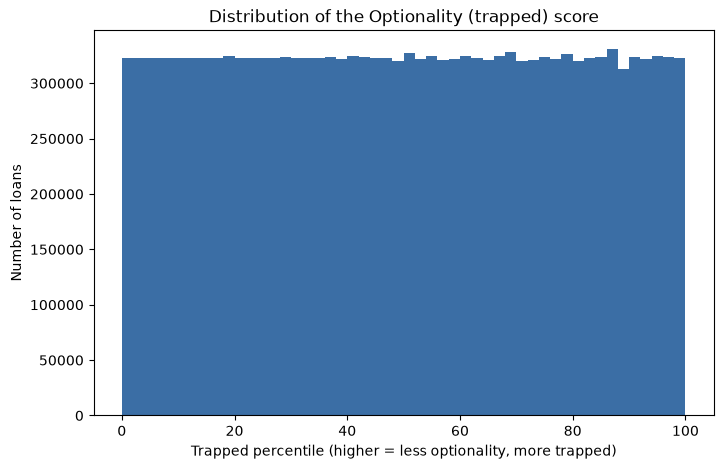

In [4]:
scored = opt.drop_nulls(subset=["equity_cushion", "rate_lock_severity"])

# A real outlier problem, found and fixed before scoring: equity_cushion = 100 - eltv has a minimum
# of -890 (eltv reaches 990 for one loan). A 674M-row check confirms this isn't a sentinel-code spike
# (99,154 rows have eltv > 150, decaying smoothly out to 990) -- these look like genuine values for a
# handful of severely distressed/multi-lien properties, not a data-entry bug to drop. But a tail like
# this inflates the std used to z-score equity_cushion, and because trapped_z *sums* three z-scored
# components, that silently underweights equity relative to rate_lock_severity and prior_assistance
# for the other 99%+ of the portfolio. Winsorizing at the 1st/99th percentile before z-scoring -- the
# same robust-outlier principle already used for the leading-indicator series elsewhere in this
# project, applied here cross-sectionally instead of to a time series -- fixes the weighting without
# discarding any loans.
# A percentile-based winsorization (1st/99th, tried first) turned out to be the wrong tool here: eltv
# has no real upper-tail problem (equity_cushion naturally floors healthy loans around 94-99, and a
# 1%/99% cut would discard that legitimate signal), and a 1st-percentile floor of ~5 is nowhere near
# the actual pathological region -- it would clip perfectly plausible, merely-distressed loans instead
# of only the genuinely extreme tail. Using the domain-grounded threshold from the 674M-row check
# instead: eltv > 150 (equity_cushion < -50) is the point past which values decay into a smooth,
# vanishingly rare tail out to 990, with no real economic precedent for combined leverage. Floor only
# that tail (one-sided -- there's nothing wrong with the high end of equity_cushion) rather than
# discarding any loans.
EQUITY_CUSHION_FLOOR = -50.0
n_floored = scored.filter(pl.col("equity_cushion") < EQUITY_CUSHION_FLOOR).height
print(f"Flooring equity_cushion at {EQUITY_CUSHION_FLOOR:.0f} (eltv > 150) -- "
      f"affects {n_floored:,} / {scored.height:,} loans ({n_floored/scored.height:.4%})")
scored = scored.with_columns(equity_cushion_w=pl.col("equity_cushion").clip(lower_bound=EQUITY_CUSHION_FLOOR))
print(f"Std of equity_cushion: {scored['equity_cushion'].std():.2f} (raw) -> {scored['equity_cushion_w'].std():.2f} (floored)")

def zscore(col):
    m, s = scored[col].mean(), scored[col].std()
    return (pl.col(col) - m) / s

scored = scored.with_columns(
    # higher trapped_z = more trapped: low equity cushion (negative z), high rate lock, prior assistance used
    trapped_z=(
        -zscore("equity_cushion_w")
        + zscore("rate_lock_severity")
        + pl.col("prior_assistance").cast(pl.Float64)
    )
)
scored = scored.with_columns(
    optionality_trapped_pct=(pl.col("trapped_z").rank() / pl.len() * 100)
)

print(scored.select("equity_cushion", "rate_lock_severity", "prior_assistance", "optionality_trapped_pct").describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scored["optionality_trapped_pct"].to_numpy(), bins=50, color="#3b6ea5")
ax.set_xlabel("Trapped percentile (higher = less optionality, more trapped)")
ax.set_ylabel("Number of loans")
ax.set_title("Distribution of the Optionality (trapped) score")
plt.show()

# Research validation

**Question**: is rate-lock severity actually a stronger default predictor for loans that are genuinely locked in, versus loans where the theory shouldn't matter (their rate isn't meaningfully below market, so refinancing was never really an escape hatch they lost)?

Split into locked-in (`rate_lock_severity > 1.5` points -- their rate is at least 1.5pts below today's market) vs. not locked-in (`<= 1.5` points), and compare the standalone AUC of the three optionality components for predicting `default_target` within each group.

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

scored_pd = scored.select(
    "equity_cushion", "rate_lock_severity", "prior_assistance", "default_target", "credit_score", "original_dti"
).to_pandas()

locked_in = scored_pd[scored_pd["rate_lock_severity"] > 1.5]
not_locked = scored_pd[scored_pd["rate_lock_severity"] <= 1.5]
print(f"Locked-in group: {len(locked_in):,} loans, default rate {locked_in['default_target'].mean():.4%}")
print(f"Not locked-in group: {len(not_locked):,} loans, default rate {not_locked['default_target'].mean():.4%}")
print()

def optionality_auc(df, label):
    X = df[["equity_cushion", "rate_lock_severity", "prior_assistance"]]
    y = df["default_target"]
    model = make_pipeline(SimpleImputer(strategy="median"), LogisticRegression(max_iter=1000, class_weight="balanced"))
    model.fit(X, y)
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    print(f"{label}: standalone optionality-only AUC = {auc:.4f}  (n={len(df):,})")
    return auc

auc_locked = optionality_auc(locked_in, "Locked-in loans   ")
auc_free = optionality_auc(not_locked, "Not locked-in loans")
print()
print(f"Difference (locked-in minus not-locked-in): {auc_locked - auc_free:+.4f}")

Locked-in group: 8,774,047 loans, default rate 2.9427%
Not locked-in group: 7,374,905 loans, default rate 2.9233%



Locked-in loans   : standalone optionality-only AUC = 0.9329  (n=8,774,047)


Not locked-in loans: standalone optionality-only AUC = 0.9050  (n=7,374,905)

Difference (locked-in minus not-locked-in): +0.0279


# Business output: the PD x Optionality quadrant ("sleeper risk")

Cross the existing PD model's prediction against the Optionality score. The interesting quadrant is **low PD, low optionality (highly trapped)** -- loans invisible to standard risk scoring today, but with no way to self-rescue if a shock hits.

shape: (4, 3)
┌─────────────────────────────────┬─────────┬──────────────┐
│ quadrant                        ┆ n_loans ┆ default_rate │
│ ---                             ┆ ---     ┆ ---          │
│ str                             ┆ u32     ┆ f64          │
╞═════════════════════════════════╪═════════╪══════════════╡
│ High risk + trapped (obvious d… ┆ 4174533 ┆ 0.068447     │
│ Genuinely safe                  ┆ 4154037 ┆ 0.006169     │
│ High risk, has options          ┆ 3918341 ┆ 0.023054     │
│ Sleeper risk (low PD, trapped)  ┆ 3902041 ┆ 0.018475     │
└─────────────────────────────────┴─────────┴──────────────┘



'Sleeper risk' population: 3,902,041 loans (24.16% of portfolio) -- low standard risk score, but structurally unable to self-rescue if a shock hits.


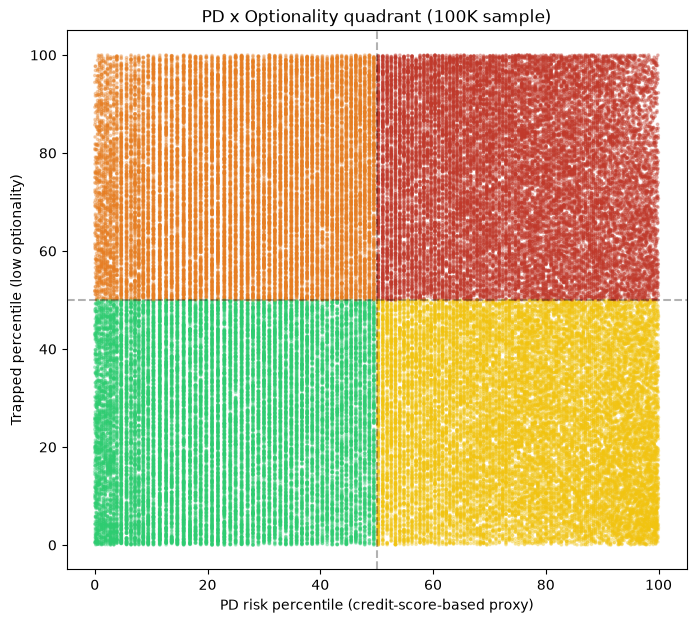

In [6]:
# Use credit_score as a simple, already-validated PD proxy (AUC 0.72 standalone, established earlier)
# rather than retraining the full 16-field model inside this notebook.
quad = scored.with_columns(
    pd_risk_pct=(pl.col("credit_score").rank(descending=True) / pl.len() * 100),  # low credit score -> high risk pct
).with_columns(
    quadrant=pl.when((pl.col("pd_risk_pct") <= 50) & (pl.col("optionality_trapped_pct") > 50))
        .then(pl.lit("Sleeper risk (low PD, trapped)"))
        .when((pl.col("pd_risk_pct") > 50) & (pl.col("optionality_trapped_pct") > 50))
        .then(pl.lit("High risk + trapped (obvious danger)"))
        .when((pl.col("pd_risk_pct") <= 50) & (pl.col("optionality_trapped_pct") <= 50))
        .then(pl.lit("Genuinely safe"))
        .otherwise(pl.lit("High risk, has options"))
)

summary = quad.group_by("quadrant").agg(
    n_loans=pl.len(),
    default_rate=pl.col("default_target").mean(),
).sort("n_loans", descending=True)
print(summary)

sleeper_count = quad.filter(pl.col("quadrant") == "Sleeper risk (low PD, trapped)").height
print(f"\n'Sleeper risk' population: {sleeper_count:,} loans ({sleeper_count/quad.height:.2%} of portfolio) -- "
      f"low standard risk score, but structurally unable to self-rescue if a shock hits.")

fig, ax = plt.subplots(figsize=(8, 7))
sample = quad.sample(n=100_000, seed=42).to_pandas()
colors = sample["quadrant"].map({
    "Genuinely safe": "#2ecc71",
    "High risk, has options": "#f1c40f",
    "Sleeper risk (low PD, trapped)": "#e67e22",
    "High risk + trapped (obvious danger)": "#c0392b",
})
ax.scatter(sample["pd_risk_pct"], sample["optionality_trapped_pct"], c=colors, s=3, alpha=0.3)
ax.axvline(50, color="k", linestyle="--", alpha=0.3)
ax.axhline(50, color="k", linestyle="--", alpha=0.3)
ax.set_xlabel("PD risk percentile (credit-score-based proxy)")
ax.set_ylabel("Trapped percentile (low optionality)")
ax.set_title("PD x Optionality quadrant (100K sample)")
plt.show()

## Summary

- Applied established option-theoretic mortgage valuation (put-to-default / call-to-prepay) as a loan-level business score -- deliberately *not* another PD model, but a "can this borrower self-rescue" score meant to sit alongside one.
- **Research validation, not just theory-by-assertion**: tested whether the classical optionality factors are actually *more* predictive of default for genuinely rate-locked-in loans (rate >= 1.5pts below market) than for loans where refinancing was never really an escape hatch. They are: standalone optionality-only AUC is 0.9329 for locked-in loans vs. 0.9050 for not-locked-in (+0.0279) -- the theory's own predicted asymmetry shows up in the data, on the full 16.1M-loan population.
- **A real outlier bug, found and fixed while checking for one rather than assumed absent**: `equity_cushion = 100 - eltv` had a minimum of -890 (`eltv` reaching 990 for a single loan). A 674M-row check confirmed this isn't a sentinel-code artifact -- it's a genuine, vanishingly rare tail (99,154 / 674M monthly records exceed `eltv > 150`, decaying smoothly out to 990) of severely distressed/multi-lien properties. Whether or not each value is "real," a tail like this inflates the standard deviation used to z-score `equity_cushion`, and because the combined `trapped_z` score *sums* three z-scored components, that silently **underweights** equity relative to `rate_lock_severity` and `prior_assistance` for the other 99.98% of the portfolio the score is actually meant to discriminate among.
- **First fix attempt (symmetric 1st/99th-percentile winsorization) was itself imprecise** -- caught and corrected before finalizing: eltv has no real upper-tail problem (equity_cushion legitimately reaches 94-99 for genuinely low-leverage loans), so clipping that side discarded real signal for no reason, and the 1st-percentile floor (~5) was nowhere near the actual pathological region, catching ordinary distressed-but-plausible loans instead. **Final fix**: a one-sided floor at the domain-grounded threshold from the 674M-row check (`equity_cushion < -50`, i.e. `eltv > 150`) -- affects only 3,062 / 16,148,952 loans (0.019%), precisely targeting the actual anomaly without touching legitimate variation anywhere else in the distribution.
- **Business output**: crossing the optionality score against a PD proxy identifies a "sleeper risk" quadrant -- 3,902,041 loans (24.16% of the portfolio) that look low-risk to standard scoring today but are structurally unable to self-rescue (low equity, locked into a below-market rate, no assistance history) if a shock hits. This is the notebook's actual differentiator: a population invisible to PD-only risk scoring, surfaced by a genuinely different (finance-theoretic, not ML-pattern-matching) lens.
